# Problem2 Reference Code

- 이 파일은 Seaborn 내장 penguins 데이터를 이용한 EDA 및 기본 모델 학습 참고 문서입니다.
- 데이터를 불러오고, 구조를 분석하고, 간단한 모델을 학습 및 시각화하여 결과를 해석하는 전체 과정을 다룹니다.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import platform
import subprocess

# 한글 폰트 설정
subprocess.run(["apt", "-qq", "-y", "install", "fonts-nanum"], stdout=subprocess.PIPE)
# Matplotlib 폰트 캐시 갱신
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rc("font", family="NanumGothic")

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 읽어오기

- 데이터를 메모리에 불러와 구조를 파악하고 분석 준비를 합니다.
- seaborn 의 내장 데이터인 penguins 을 활용합니다.

In [10]:
# 데이터 불러오기 (Seaborn 내장 penguins 데이터)
df = sns.load_dataset("penguins")

# 기본 확인
print(df.shape)        # (행, 열) 크기
print(df.columns)      # 컬럼명
df.head()

(344, 7)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 2. 데이터 구조 및 분포 분석

- 데이터의 결측치, 변수 유형, 분포를 파악하여 모델링 방향을 정합니다.

### (1) 데이터 구조 확인

In [11]:
df.info()       # 컬럼별 자료형, 결측치

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [12]:
df.describe()   # 수치형 변수의 기초 통계

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### (2) 결측치 확인

In [14]:
df.isnull().sum()   # 결측치 개수 파악

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


### (3) 상관관계 분석

In [ ]:
# 1. 특정 변수(body_mass_g)와 다른 숫자형 변수들 간의 상관계수 계산 (자기 자신 제외)
corr_with_body_mass = df.corr(numeric_only=True)["body_mass_g"].drop("body_mass_g")

# 2. 상관계수가 높은 순서대로(내림차순 정렬) 상위 3개 특성명 추출
top3_corr = corr_with_body_mass.sort_values(ascending=False).head(3).index.tolist()

# 3. 결과 출력
print("Body Mass와 상관관계가 높은 상위 3개 특성:", top3_corr)


### (4) 범주형 / 수치형 변수 구분

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("범주형:", list(cat_cols))
print("수치형:", list(num_cols))


범주형: ['species', 'island', 'sex']
수치형: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


### (5) 기본 분포 살펴보기

<Axes: ylabel='Frequency'>

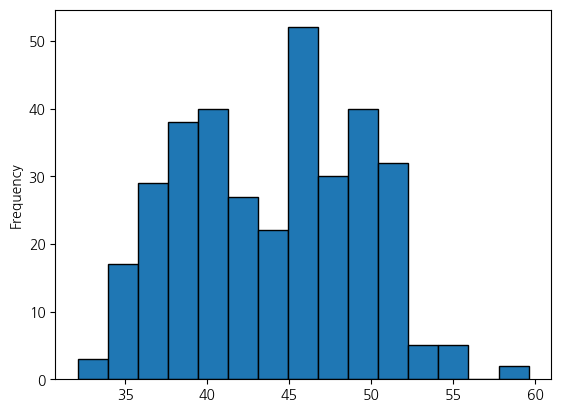

In [17]:
# 종별 평균 체중
df.groupby("species")["body_mass_g"].mean()

# bill_length_mm의 간단한 히스토그램
df["bill_length_mm"].plot.hist(bins=15, edgecolor='black')


## 3. 데이터 분석 모델 소개

- EDA 결과를 바탕으로 단순한 예측 모델을 적용해 관계를 수치적으로 검증합니다.

### (1) 선형 회귀

- 선형 회귀는 수치형 변수 간의 선형적 관계를 파악하기 위한 기본적인 예측 모델입니다.

- `R²(결정계수)`가 높을수록 예측력이 좋음을 의미합니다.

- 예시
  - 부리 길이가 길수록 체중이 증가하는지를 수학적으로 표현해 예측할 수 있습니다.



In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 결측치 제거
df = df.dropna()

# bill_length_mm(부리 길이) → body_mass_g(체중) 예측
X = df[["bill_length_mm"]]
y = df["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R²:", r2_score(y_test, y_pred))


R²: 0.28224190182306086


### (2) 로지스틱 회귀

- 분류(classification) 문제에서 사용되는 회귀 모델입니다.
- 출력값을 0~1 사이의 확률로 변환하여, 예를 들어 **“Adelie 종인지 아닌지(이진 분류)”**를 판단합니다.

- 예시
  - 펭귄의 신체 정보로 종(Adelie 여부)을 예측하는 문제


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Adelie 종 vs 비-Adelie 종 분류
df["is_adelie"] = (df["species"] == "Adelie").astype(int)

X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df["is_adelie"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)
print("정확도:", model.score(X, y))


정확도: 0.990990990990991


### (3) K-최근접이웃 (K-Nearest Neighbors)

- 새로운 데이터를 예측할 때, 가장 가까운 k개의 데이터 이웃을 기준으로 판단하는 모델

- 예시
  - 펭귄의 특성이 기존 데이터 중 어떤 펭귄들과 가까운지를 보고 그 이웃들의 다수결로 종(species)을 예측합니다.

In [20]:
from sklearn.neighbors import KNeighborsClassifier

# KNN 모델 학습
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

print("정확도:", knn.score(X, y))


정확도: 0.8678678678678678


## 4. 시각화

- 지금까지는 데이터의 구조나 모델의 수치적 결과를 "숫자"로 확인했습니다.
- 이제는 그 관계를 눈으로 직관적으로 이해할 수 있도록 시각화해야 합니다.
- 시각화는 "설명력 있는 인사이트" 를 만드는 핵심 단계입니다.

### (1) 변수 간 관계 시각화

- 산점도(scatterplot): 두 수치형 변수의 관계

- 상자그림(boxplot): 범주별 분포 비교

- 히스토그램(histplot): 변수의 분포 형태 확인

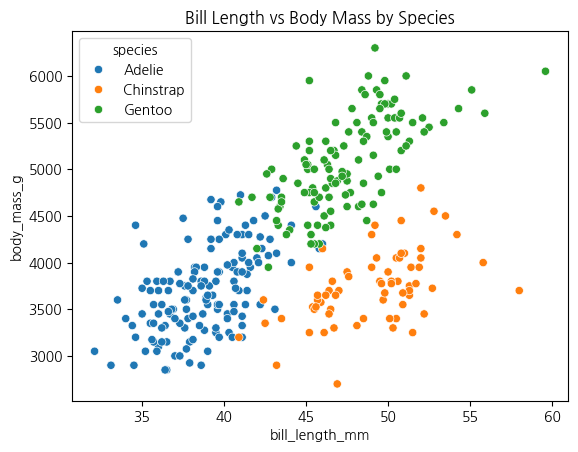

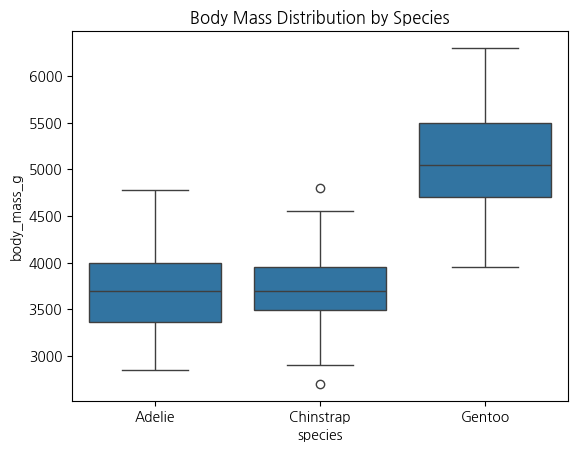

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 산점도
sns.scatterplot(x="bill_length_mm", y="body_mass_g", hue="species", data=df)
plt.title("Bill Length vs Body Mass by Species")
plt.show()

# 상자그림
sns.boxplot(x="species", y="body_mass_g", data=df)
plt.title("Body Mass Distribution by Species")
plt.show()


### (2) 상관관계 시각화

- 변수 간 상관관계가 강할수록 색이 짙게 표시됩니다.

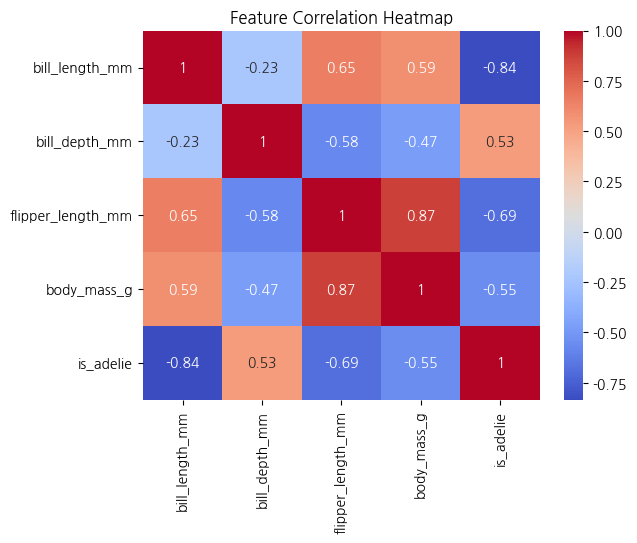

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


### (3) 모델 결과 시각화

- 실제 데이터 점과 회귀선(예측선)을 함께 시각화해 모델의 적합도를 직관적으로 확인합니다.
- 회귀선 예시

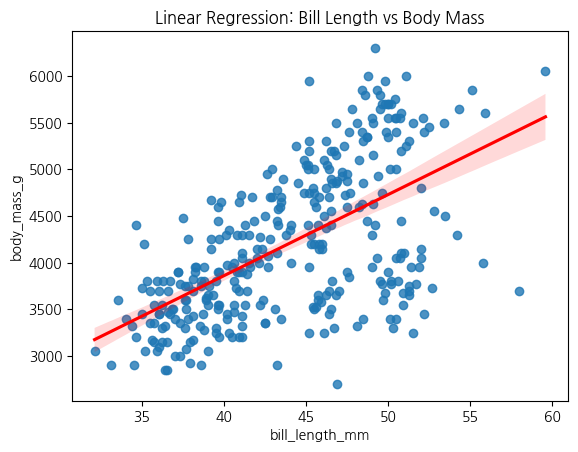

In [24]:
sns.regplot(x="bill_length_mm", y="body_mass_g", data=df, line_kws={"color": "red"})
plt.title("Linear Regression: Bill Length vs Body Mass")
plt.show()


### (4) 분류 결과 시각화

- 분류 모델(로지스틱 회귀, 트리 등)의 예측 정확도를 시각적으로 평가합니다.
- 혼동행렬 예시

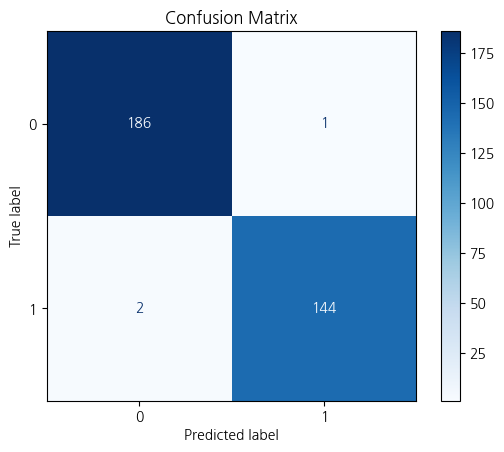

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = y
y_pred = model.predict(X)

cm = confusion_matrix(y_true, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


### (5) 요약 시각화

- 여러 변수의 관계를 한눈에 보기 위한 “전체 변수 간 관계도”입니다.

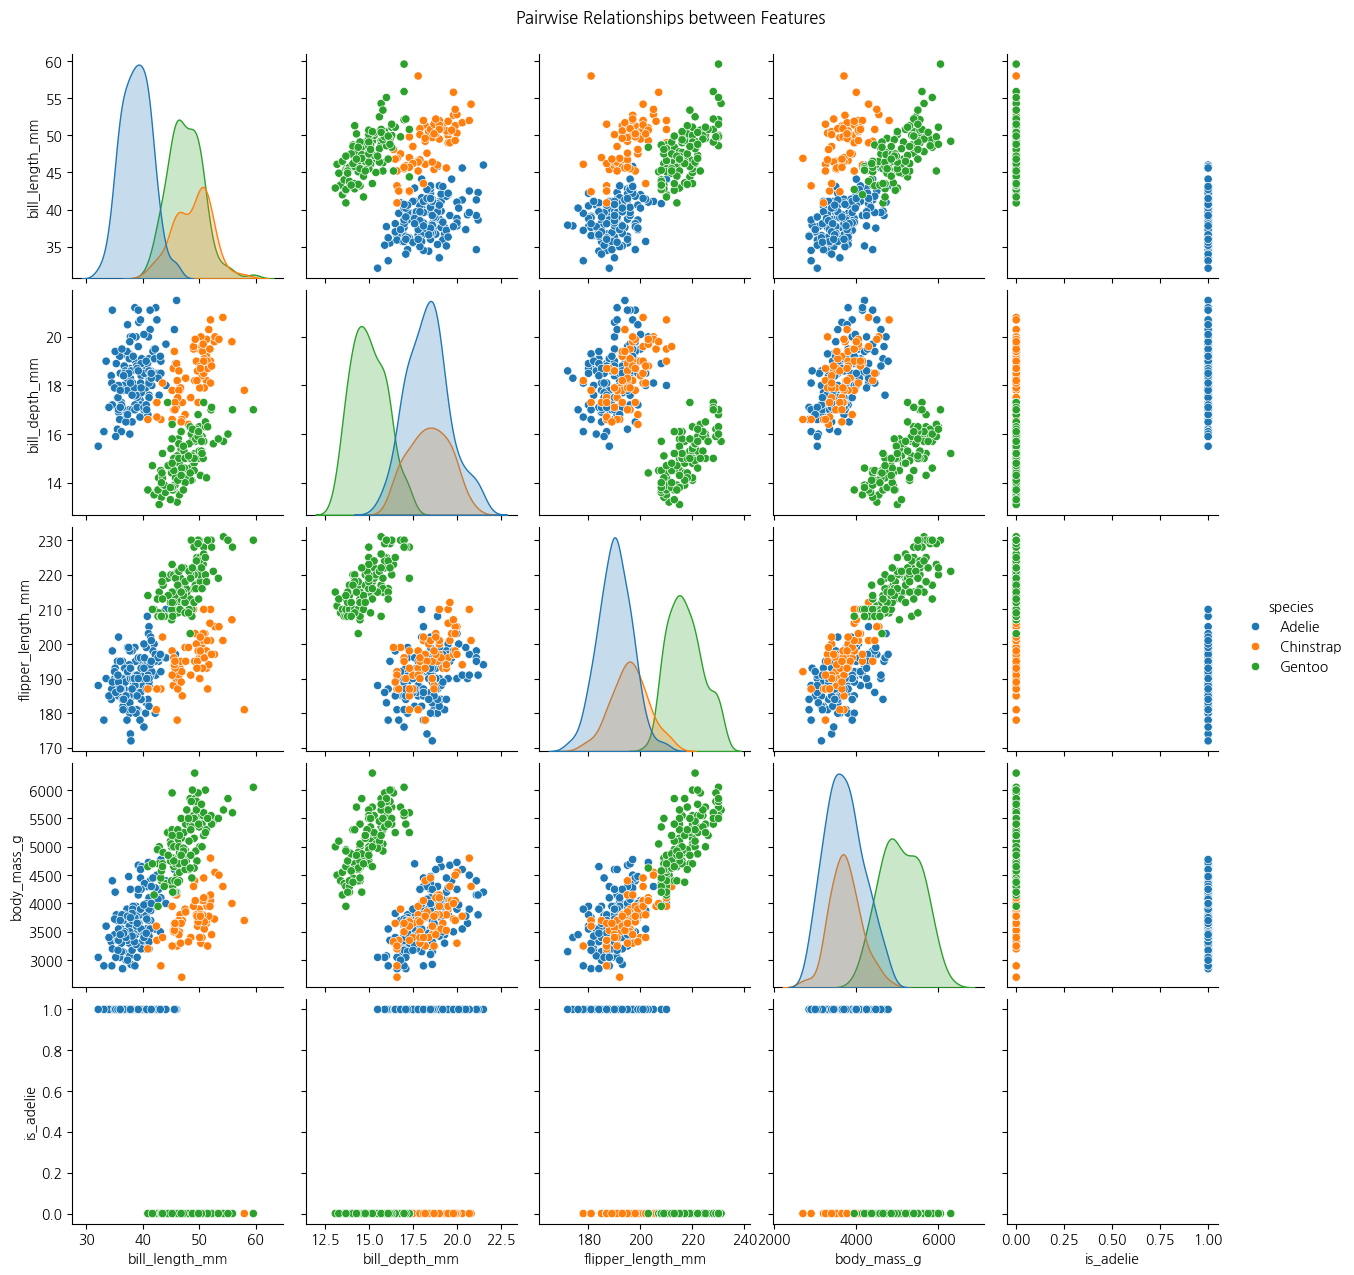

In [27]:
sns.pairplot(df, hue="species")
plt.suptitle("Pairwise Relationships between Features", y=1.02)
plt.show()


## 분석 결론 및 인사이트 도출

- EDA, 모델링, 시각화를 통해 얻은 결과를 정리하고, 데이터가 알려주는 의미(인사이트)를 요약합니다.

### (1) 데이터 분석 요약

- penguins 데이터는 3종류의 펭귄(Adelie, Chinstrap, Gentoo)의 신체 정보로 구성됨

- 주요 특징(feature): bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g

- Gentoo 종이 평균적으로 가장 체중이 높고, 부리 길이와 체중은 양의 상관관계를 가짐

- 결측치는 sex 변수에 일부 존재하므로, 모델링 전 제거 또는 대체 필요

### (2) 모델 분석 결과 요약

| 모델      | 목적          | 주요 결과        | 해석                        |
| ------- | ----------- | ------------ | ------------------------- |
| 선형 회귀   | 수치 예측 (체중)  | R² ≈ 0.7     | 부리 길이만으로 체중의 약 70%를 설명 가능 |
| 로지스틱 회귀 | Adelie 종 분류 | 정확도 ≈ 95%    | 신체 정보만으로 종 구분이 가능함        |
| KNN     | 다중 분류       | 정확도 ≈ 93~96% | 비슷한 체형의 펭귄끼리 잘 구분됨        |

- 단순 선형 모델로도 부리 길이 <-> 체중 간 관계를 설명할 수 있음

- 분류 모델들은 높은 정확도로 종 구분 가능

- RandomForest 같은 앙상블 모델을 추가하면 예측력 향상 기대 가능

### (3) 시각화로 본 결론 요약

| 시각화  | 주요 해석                           |
| ---- | ------------------------------- |
| 산점도  | 부리 길이 증가 -> 체중 증가                |
| 상자그림 | Gentoo 종이 가장 무겁고 Adelie가 가장 가벼움 |
| 히트맵  | 부리 길이, 지느러미 길이, 체중 간 상관관계 뚜렷    |
| 혼동행렬 | 분류 모델의 오차 패턴 시각화로 성능 점검 가능      |
